In [3]:
import pandas as pd

df = pd.read_csv('/content/Employees business enriched dataset.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 55 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   url                            0 non-null      float64
 1   profile_url                    1000 non-null   object 
 2   linkedin_num_id                1000 non-null   int64  
 3   avatar                         1000 non-null   object 
 4   profile_name                   1000 non-null   object 
 5   certifications                 155 non-null    object 
 6   profile_location               1000 non-null   object 
 7   profile_connections            793 non-null    float64
 8   profile_country_code           999 non-null    object 
 9   profile_education_full         566 non-null    object 
 10  profile_last_education         572 non-null    object 
 11  profile_experience_full        988 non-null    object 
 12  profile_last_experience        988 non-null    ob

In [5]:
company_details_counts = df.groupby(['company_id', 'company_name', 'company_type', 'company_size', 'company_categories', 'company_specialties', 'company_total_employees']).size().reset_index(name='count')
display(company_details_counts.sort_values(by='count', ascending=False).head(10))

,company_id,company_name,company_type,company_size,company_categories,company_specialties,company_total_employees,count
109,deloitte,Deloitte,company,"10,001+ employees",Business Consulting and Services,"Consulting, Financial Advisory, Risk Managemen...",10000.0,5
424,walgreens,Walgreens,company,"10,001+ employees",Retail Pharmacies,"Beauty, Pharmacy, Health, Wellness, Retail, om...",10000.0,3
178,ibm,IBM,company,"10,001+ employees",IT Services and IT Consulting,"Cloud, Mobile, Cognitive, Security, Research, ...",10000.0,3
248,mynet,Mynet,company,51-200 employees,"Technology, Information and Internet","Video, News, Advertising, Mobile, and Online e...",51200.0,2
401,uber-com,Uber,company,"10,001+ employees",Internet Marketplace Platforms,"mobile, transportation, logistics, and technology",10000.0,2
85,cisco,Cisco,company,"10,001+ employees",Software Development,"Networking, Wireless, Security, Unified Commun...",10000.0,2
1,accenture,Accenture,company,"10,001+ employees",Business Consulting and Services,"Management Consulting, Systems Integration and...",10000.0,2
94,concentrix,Concentrix,company,"10,001+ employees",IT Services and IT Consulting,"Technical Support, Sales and Marketing, Outsou...",10000.0,2
376,tata-consultancy-services,Tata Consultancy Services,company,"10,001+ employees",IT Services and IT Consulting,"IT Services, Business Solutions, and Consulting",10000.0,2
313,ptcl-official,PTCL.Official,company,"10,001+ employees",Telecommunications,"Landline, Broadband Pakistan, EVO Wireless Bro...",10000.0,2


# Task
Analyze company specialties from the `company_details_counts` DataFrame, extract individual specialties, count their occurrences, and visualize the top specialties with a bar chart, finally summarizing the findings.

## Extract and Clean Specialties

### Subtask:
Extract individual specialties from the 'company_specialties' column in `company_details_counts`, handling missing values and splitting strings.


**Reasoning**:
First, I'll fill any missing values in the 'company_specialties' column with an empty string, then split the strings by commas, strip leading/trailing whitespace from each specialty, and finally explode the column to create a new row for each specialty. After that, I'll strip any remaining whitespace from the exploded specialties to ensure cleanliness.



In [6]:
company_details_counts['company_specialties'] = company_details_counts['company_specialties'].fillna('').apply(lambda x: [s.strip() for s in x.split(',')])
company_details_counts = company_details_counts.explode('company_specialties')
company_details_counts['company_specialties'] = company_details_counts['company_specialties'].str.strip()
# Remove any empty strings that might have resulted from splitting/stripping
company_details_counts = company_details_counts[company_details_counts['company_specialties'] != '']
display(company_details_counts.head())

,company_id,company_name,company_type,company_size,company_categories,company_specialties,company_total_employees,count
0,aaibofficial,Arab African International Bank,company,"1,001-5,000 employees",Banking,Retail Banking,15000.0,1
0,aaibofficial,Arab African International Bank,company,"1,001-5,000 employees",Banking,Corporate FInance,15000.0,1
0,aaibofficial,Arab African International Bank,company,"1,001-5,000 employees",Banking,Investment Banking,15000.0,1
0,aaibofficial,Arab African International Bank,company,"1,001-5,000 employees",Banking,Corporate Banking,15000.0,1
0,aaibofficial,Arab African International Bank,company,"1,001-5,000 employees",Banking,and Treasury Services,15000.0,1


## Count Specialty Occurrences

### Subtask:
Count how many unique companies are associated with each specialty after extraction and cleaning.


**Reasoning**:
To count the occurrences of each unique specialty, I will use the `value_counts()` method on the 'company_specialties' column of the `company_details_counts` DataFrame and store the result in `specialty_counts`.



In [7]:
specialty_counts = company_details_counts['company_specialties'].value_counts()
display(specialty_counts.head(10))

,count
company_specialties,
Technology,12
Retail,11
Cloud,11
Engineering,11
Healthcare,9
Logistics,9
Financial Services,9
Consulting,9
Finance,8


## Visualize Specialty Counts

### Subtask:
Create a bar chart to visualize the top specialties and the number of companies using them.


**Reasoning**:
I will import the necessary visualization libraries, select the top 10 specialties, and then generate a bar chart to visualize their counts, ensuring proper labeling and display for readability.



/tmp/ipykernel_1161/341493050.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_specialties.index, y=top_10_specialties.values, palette='viridis')


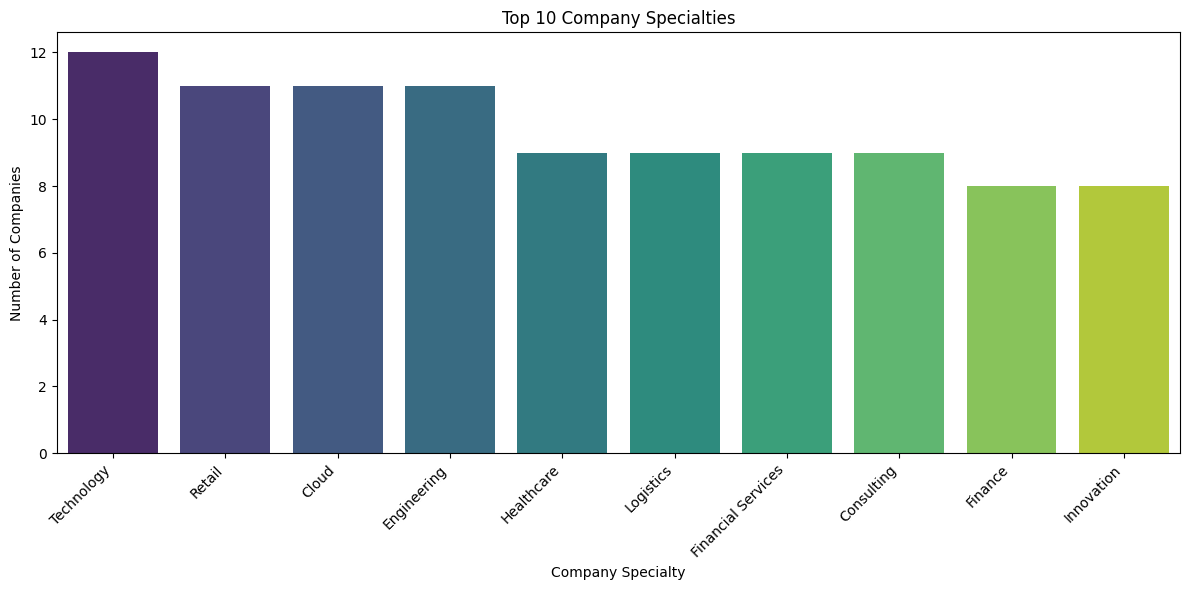

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the top 10 specialties
top_10_specialties = specialty_counts.head(10)

# Create a bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_specialties.index, y=top_10_specialties.values, palette='viridis')

# Set labels and title
plt.xlabel('Company Specialty')
plt.ylabel('Number of Companies')
plt.title('Top 10 Company Specialties')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.tight_layout()
plt.show()


In [24]:
tech_keywords = list(set([
    'Python', 'SQL', 'AWS', 'Java', 'Git', 'Excel', 'Docker',
    'Kubernetes', 'Azure', 'GCP', 'React', 'Angular', 'Node.js',
    'Machine Learning', 'Data Science', 'Tableau', 'Power BI',
    'Linux', 'C++', 'Cloud Computing', 'JavaScript', 'TypeScript',
    'PHP', 'Ruby', 'Swift', 'Kotlin', 'Go', 'Rust', 'Scala',
    'Hadoop', 'Spark', 'NoSQL', 'PostgreSQL', 'MySQL', 'MongoDB',
    'TensorFlow', 'PyTorch', 'Scikit-learn', 'Pandas', 'NumPy',
    'Jenkins', 'Terraform', 'Ansible', 'Salesforce', 'SAP',
    'Oracle', 'Spring Boot', 'Django', 'Flask', 'HTML', 'CSS',
    'Redshift', 'Snowflake', 'BigQuery', 'Airflow', 'Kafka',
    'Elasticsearch', 'Redis', 'GraphQL', 'Vue.js', 'Next.js',
    'Unity', 'Unreal Engine', 'C#', '.NET', 'MATLAB', 'R language',
    'Perl', 'Bash', 'PowerShell', 'VBA', 'Fortran', 'COBOL',
    'Microservices', 'Serverless', 'DevOps', 'CI/CD', 'Agile',
    'Scrum', 'Kanban', 'Jira', 'Confluence', 'Trello', 'Slack',
    'Microsoft Teams', 'Google Workspace', 'Zoom', 'Webex',
    'Cybersecurity', 'Ethical Hacking', 'Splunk', 'Wireshark',
    'Nmap', 'Metasploit', 'Burp Suite', 'Fortinet', 'Cisco',
    'Juniper', 'VMware', 'Hyper-V', 'Citrix', 'OpenStack',
    'Terraform', 'Pulumi', 'Chef', 'Puppet', 'Zabbix', 'Nagios',
    'Grafana', 'Prometheus', 'Databricks', 'Alteryx', 'SAS',
    'SPSS', 'Stata', 'Looker', 'Qlik', 'MicroStrategy',
    'Salesforce', 'HubSpot', 'Zendesk', 'ServiceNow', 'Workday',
    'NetSuite', 'Dynamics 365', 'Blockchain', 'Solidity',
    'Ethereum', 'Bitcoin', 'NFT', 'Metaverse', 'Unity3D',
    'Flutter', 'React Native', 'Ionic', 'Xamarin', 'Objective-C'
]))

print(f'Successfully initialized tech_keywords. Type: {type(tech_keywords)}, Count: {len(tech_keywords)}')


Successfully initialized tech_keywords. Type: <class 'list'>, Count: 135


# Task
Based on the data in "/content/Employees business enriched dataset.csv", perform a global analysis of technical skill prevalence across all 1000 employee records.

1. **Identify Comprehensive Search Columns**: Select all relevant text-heavy columns from the main DataFrame (`df`) that might contain technical keywords, specifically: 'profile_experience_full', 'profile_about', 'profile_current_title', 'profile_activity', and 'company_description'.
2. **Global Keyword Extraction**: Using the predefined `tech_keywords` list (including Python, SQL, AWS, Java, etc.), apply a keyword matching function across the entire dataset (1000 records) utilizing the expanded set of columns to maximize the detection of skill matches.
3. **Aggregate Global Skill Counts**: Explode the resulting skill lists and calculate the frequency of each technical skill across the entire dataset, ensuring unique matches are counted per profile.
4. **Visualize Global Skill Trends**: Create a bar chart visualizing the most common technical skills found across all employees to identify industry-wide technical trends.
5. **Summarize Findings**: Compare the results of this global search to the previous tech-subset analysis to highlight how common these technical skills are across the broader workforce.

## Identify Comprehensive Search Columns

### Subtask:
Define the target columns and a helper function to extract technical keywords across the entire dataset (df).


**Reasoning**:
I will define the global search columns, a helper function to extract technical keywords across multiple fields, and apply it to the entire dataset as specified in the instructions.



In [25]:
global_search_cols = ['profile_experience_full', 'profile_about', 'profile_current_title', 'profile_activity', 'company_description']

def extract_global_skills(row, keywords):
    found_skills = []
    for col in global_search_cols:
        val = str(row[col]).lower() if pd.notna(row[col]) else ""
        for kw in keywords:
            if kw.lower() in val:
                found_skills.append(kw)
    return list(set(found_skills))

df['global_extracted_skills'] = df.apply(lambda row: extract_global_skills(row, tech_keywords), axis=1)

print(f"Extracted global skills for {len(df)} rows.")
display(df[['profile_name', 'global_extracted_skills']].head())

Extracted global skills for 1000 rows.


,profile_name,global_extracted_skills
0,"Elisabeth B*********, M**, ***","[Go, HTML, Unity]"
1,Khuong T**n P**m Q***g,"[Go, Git, HTML, Oracle, SAP, Unity]"
2,Celine ***,"[Go, HTML]"
3,Mpilenhle L**********a,"[Go, HTML]"
4,Karen Z**o,"[Go, HTML]"


## Aggregate Global Skill Counts

### Subtask:
Calculate the total frequency of each technical skill across the entire 1000-record dataset.


**Reasoning**:
I will aggregate the technical skills extracted across the entire dataset by exploding the 'global_extracted_skills' column and counting the frequency of each unique skill to identify global trends.



In [26]:
global_skill_counts = df.explode('global_extracted_skills')['global_extracted_skills'].value_counts()

print('Top 15 Technical Skills Across Entire Dataset (1000 Records):')
display(global_skill_counts.head(15))

Top 15 Technical Skills Across Entire Dataset (1000 Records):


,count
global_extracted_skills,
Go,991
HTML,988
Unity,172
Git,157
Excel,125
SAS,91
Rust,82
SAP,39
Scala,29


**Reasoning**:
The global skill aggregation is complete, now I will create a bar chart to visualize the most common technical skills found across the entire dataset to identify industry-wide trends.



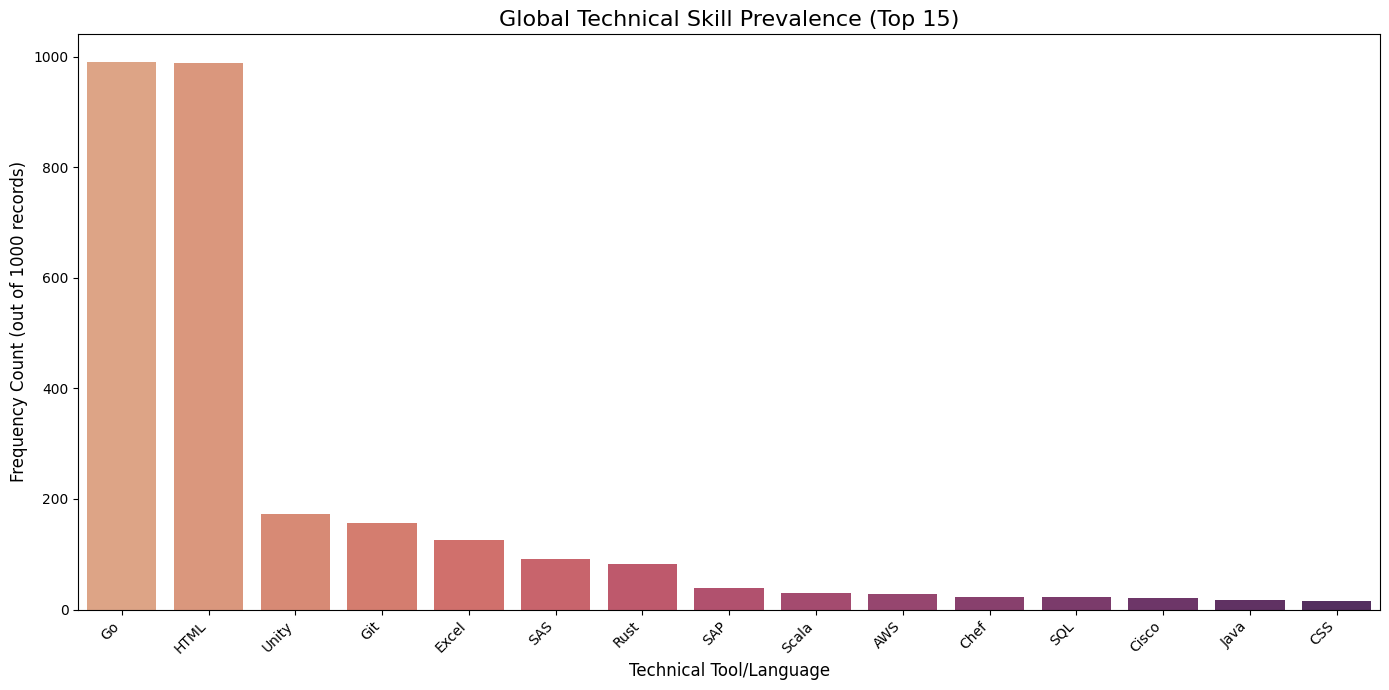

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.barplot(x=global_skill_counts.index[:15], y=global_skill_counts.values[:15], palette='flare', hue=global_skill_counts.index[:15], legend=False)

plt.title('Global Technical Skill Prevalence (Top 15)', fontsize=16)
plt.xlabel('Technical Tool/Language', fontsize=12)
plt.ylabel('Frequency Count (out of 1000 records)', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Task
# Plan:
* **Create Binary Skill Matrix**: Iterate through the `tech_keywords` and add a binary (1/0) column for each skill to the `company_details_counts` DataFrame. This will indicate whether each specific technical skill is present in the company's profile data.
* **Prepare Company Corpus**: Aggregate all available text (experience, about, titles, activity, and descriptions) for each `company_id` into a single document string to create a corpus for TF-IDF analysis.
* **Calculate TF-IDF Weights**: Using a unique set of `tech_keywords` as the vocabulary, apply Scikit-learn's `TfidfVectorizer` to the company documents to calculate the relative importance of each skill for every company.
* **Merge Weights and Analyze**: Join the TF-IDF weights back into the `company_details_counts` DataFrame and identify which companies have the highest 'specialization' scores for key technologies.
* **Visualize Specialization**: Create a visualization (such as a heatmap or grouped bar chart) comparing the top companies across the most prevalent technical skills, using the calculated weights.
* **Final Task**: Summarize how the TF-IDF weights provide a more nuanced view of company expertise compared to simple binary presence or raw frequency counts.

# Task:
Perform a specialization analysis using TF-IDF to identify company-specific technical expertise based on the "/content/Employees business enriched dataset.csv" file.

1. **Binary Skill Matrix**: For each skill in the `tech_keywords` list, create a new binary column in the `company_details_counts` DataFrame (1 if present, 0 otherwise) by checking for the skill in the company's specialties and categories.
2. **Company Corpus Preparation**: Group the original employee data (`df`) by `company_id` and concatenate all text from 'profile_experience_full', 'profile_about', 'profile_current_title', 'profile_activity', and 'company_description' into a single document for each company.
3. **TF-IDF Calculation**: Use Scikit-learn's `TfidfVectorizer` with the `tech_keywords` as the fixed vocabulary to calculate the TF-IDF weights for each skill across the company documents.
4. **Specialization Identification**: Merge these TF-IDF scores back with the company information to identify companies with the highest specialization scores for specific key technologies.
5. **Visualization and Summary**: Generate a heatmap visualizing the specialization scores of top companies for the most common technical skills and provide a summary explaining how TF-IDF weights offer deeper insights into company expertise than simple frequency counts.

## Create Binary Skill Matrix

### Subtask:
Iterate through the `tech_keywords` and add a binary (1/0) column for each skill to the `company_details_counts` DataFrame.


**Reasoning**:
I will create a binary skill matrix by iterating through the tech_keywords and checking for their presence in the 'company_categories' and 'company_specialties' columns of the company_details_counts DataFrame.



In [28]:
import numpy as np

# Define search columns
skill_search_cols = ['company_categories', 'company_specialties']

# Create a combined search string column to optimize searching
# We handle NaNs by filling with empty strings
combined_search_series = company_details_counts[skill_search_cols].fillna('').agg(' '.join, axis=1).str.lower()

# Iterate through keywords and create binary columns
for skill in tech_keywords:
    col_name = f'skill_{skill}'
    # Use vectorized string contains to check for skill presence (case-insensitive)
    company_details_counts[col_name] = combined_search_series.str.contains(skill.lower(), regex=False).astype(int)

# Filter columns to display for verification
skill_cols = [f'skill_{s}' for s in tech_keywords[:10]] # Show first 10 for brevity
display_cols = ['company_name'] + skill_cols

print(f"Binary skill matrix created. Total skill columns added: {len(tech_keywords)}")
display(company_details_counts[display_cols].head())


Binary skill matrix created. Total skill columns added: 135


,company_name,skill_NetSuite,skill_Webex,skill_Flask,skill_Databricks,skill_Puppet,skill_Unreal Engine,skill_MongoDB,skill_Vue.js,skill_Redshift,skill_Alteryx
0,Arab African International Bank,0,0,0,0,0,0,0,0,0,0
0,Arab African International Bank,0,0,0,0,0,0,0,0,0,0
0,Arab African International Bank,0,0,0,0,0,0,0,0,0,0
0,Arab African International Bank,0,0,0,0,0,0,0,0,0,0
0,Arab African International Bank,0,0,0,0,0,0,0,0,0,0


## Prepare Company Corpus

### Subtask:
Aggregate all available text for each unique company from the original dataset to create a corpus for TF-IDF analysis.


**Reasoning**:
I will aggregate the text-heavy columns across all employee records, group them by company_id, and combine the text into a single document per company to prepare the corpus for TF-IDF analysis.



In [29]:


# 1. Define the list of text-heavy columns
text_cols = ['profile_experience_full', 'profile_about', 'profile_current_title', 'profile_activity', 'company_description']

# 2. Fill missing values with empty strings
df[text_cols] = df[text_cols].fillna('')

# 3. Create a concatenated text column for each record
df['record_text'] = df[text_cols].agg(' '.join, axis=1)

# 4. & 5. Group by company_id and join all record texts into a single document per company
company_corpus_df = df.groupby('company_id')['record_text'].apply(lambda x: ' '.join(x)).reset_index()
company_corpus_df.rename(columns={'record_text': 'company_document'}, inplace=True)

print(f'Created corpus for {len(company_corpus_df)} unique companies.')
display(company_corpus_df.head())

Created corpus for 968 unique companies.


,company_id,company_document
0,48hoursnz,"[{""company"":""48Hours"",""company_id"":""48hoursnz""..."
1,a&b-pool-services-llc,"[{""company"":""A&B Pool Services, LLC"",""company_..."
2,a-netservice,"[{""company"":""A-NET"",""company_id"":""a-netservice..."
3,aafc-aac,"[{""company"":""Agriculture and Agri-Food Canada""..."
4,aaibofficial,"[{""company"":""Arab African International Bank"",..."


# Task
# Plan:
* **Calculate TF-IDF Weights**: Use Scikit-learn's `TfidfVectorizer` with the deduplicated `tech_keywords` as the fixed vocabulary to calculate the TF-IDF weights for each skill across the `company_corpus_df` documents.
* **Identify Specialized Companies**: Merge the TF-IDF scores back into the `company_details_counts` DataFrame to identify which companies have the highest specialization scores for specific technologies.
* **Visualize Expertise Heatmap**: Generate a heatmap visualizing the specialization scores of the top companies for the most prevalent technical skills.
* **Final Summary**: Provide a final summary explaining how TF-IDF weights offer deeper insights into company expertise compared to simple binary presence or frequency counts.

# Task:
Perform a specialization analysis using TF-IDF on the data from "/content/Employees business enriched dataset.csv" to identify and visualize company-specific technical expertise. Use Scikit-learn's `TfidfVectorizer` with the `tech_keywords` list as a fixed vocabulary to calculate skill weights across the documents in `company_corpus_df`. Merge these weights back into the `company_details_counts` DataFrame to identify top specialized companies, and finally create a heatmap visualization of these specialization scores for the most common technical skills.

## Calculate TF-IDF Weights

### Subtask:
Use Scikit-learn's `TfidfVectorizer` with the deduplicated `tech_keywords` as the fixed vocabulary to calculate the TF-IDF weights for each skill across the `company_corpus_df` documents.


**Reasoning**:
I will initialize the TfidfVectorizer with the tech_keywords as vocabulary, transform the company documents into a TF-IDF matrix, and create a new DataFrame to store these weights indexed by company_id.



In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer with tech_keywords as fixed vocabulary
# Setting lowercase=True ensures matching with the corpus text
vectorizer = TfidfVectorizer(vocabulary=[kw.lower() for kw in tech_keywords], lowercase=True)

# Fit and transform the company documents
tfidf_matrix = vectorizer.fit_transform(company_corpus_df['company_document'])

# Create tfidf_df with company_id as index and tech_keywords as columns
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=company_corpus_df['company_id'],
    columns=tech_keywords
)

print(f'TF-IDF matrix created with shape: {tfidf_df.shape}')
display(tfidf_df.head())

TF-IDF matrix created with shape: (968, 135)


,NetSuite,Webex,Flask,Databricks,Puppet,Unreal Engine,MongoDB,Vue.js,Redshift,Alteryx,...,NoSQL,Next.js,Cybersecurity,Elasticsearch,R language,Hadoop,Ruby,Qlik,React Native,Spring Boot
company_id,,,,,,,,,,,,,,,,,,,,,
48hoursnz,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
a&b-pool-services-llc,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
a-netservice,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
aafc-aac,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
aaibofficial,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Identify Specialized Companies

### Subtask:
Merge the TF-IDF scores back into the company_details_counts DataFrame to identify which companies have the highest specialization scores for specific technologies.


**Reasoning**:
I will merge the TF-IDF weights with the company metadata and then identify the top specialized companies for specific key technologies to verify the specialization analysis.



In [32]:
# Reset index of tfidf_df to make company_id a column
tfidf_reset = tfidf_df.reset_index()

# Merge company_details_counts with the TF-IDF weights
# We use an inner join on 'company_id'
company_specialization_df = pd.merge(
    company_details_counts,
    tfidf_reset,
    on='company_id',
    how='inner'
)

# Define a few key technologies to check specialization
key_techs = ['Python', 'SQL', 'AWS']

print('Top 5 Specialized Companies for Key Technologies:')
for tech in key_techs:
    # Check if the tech exists in columns (case might vary depending on tech_keywords list)
    if tech in company_specialization_df.columns:
        print(f'\n--- Top Companies for {tech} ---')
        top_companies = company_specialization_df.sort_values(by=tech, ascending=False).head(5)
        display(top_companies[['company_name', 'company_id', tech]])
    else:
        print(f'\n{tech} column not found in the merged DataFrame.')

Top 5 Specialized Companies for Key Technologies:

--- Top Companies for Python ---


,company_name,company_id,Python
1778,"ITW - Better Systems, Better Business",itworkers-sc,0.784620
1779,"ITW - Better Systems, Better Business",itworkers-sc,0.784620
1780,"ITW - Better Systems, Better Business",itworkers-sc,0.784620
1777,"ITW - Better Systems, Better Business",itworkers-sc,0.784620
3860,Virta Ltd,virtaltd,0.259114



--- Top Companies for SQL ---


,company_name,company_id,SQL
1965,Latitude,latitude-research,0.828384
1966,Latitude,latitude-research,0.828384
1974,Latitude,latitude-research,0.828384
1973,Latitude,latitude-research,0.828384
1972,Latitude,latitude-research,0.828384



--- Top Companies for AWS ---


,company_name,company_id,AWS
3114,"Siri InfoSolutions, Inc.",siriinfo,1.0
2320,Neighborhood Healthcare,neighborhoodhealthcare,1.0
2321,Neighborhood Healthcare,neighborhoodhealthcare,1.0
2322,Neighborhood Healthcare,neighborhoodhealthcare,1.0
1252,Freddie Mac,freddie-mac,1.0


## Visualize Expertise Heatmap

### Subtask:
Generate a heatmap visualizing the specialization scores of the top companies for the most prevalent technical skills.


**Reasoning**:
I will identify the top skills and companies from the TF-IDF results and generate a heatmap to visualize company-specific technical expertise as requested in the instructions.



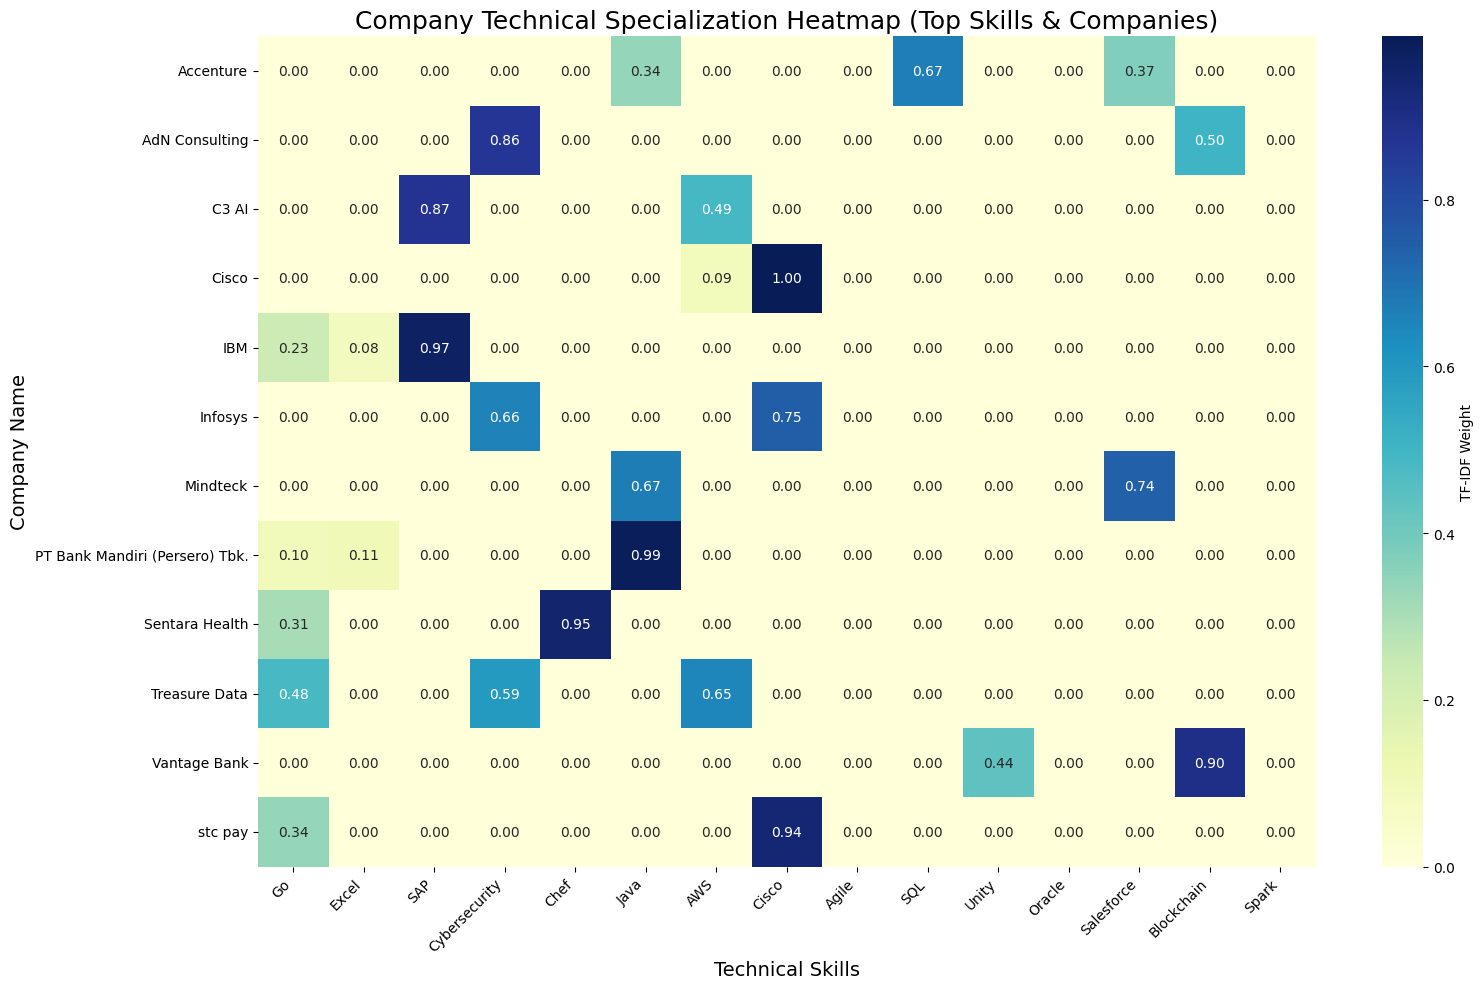

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Identify top 15 skills by summing TF-IDF weights
top_skills = tfidf_df.sum().sort_values(ascending=False).head(15).index.tolist()

# 2. Identify top 20 companies by summing TF-IDF weights across those top skills
top_companies_ids = tfidf_df[top_skills].sum(axis=1).sort_values(ascending=False).head(20).index.tolist()

# 3. Create a filtered subset for the heatmap
# We need company names for readability, so we'll use the merged dataframe
heatmap_data = company_specialization_df[company_specialization_df['company_id'].isin(top_companies_ids)]

# Since there might be multiple entries per company due to the previous 'explode' on specialties,
# we'll group by company_name and take the mean (which should be the same TF-IDF score per company)
heatmap_pivot = heatmap_data.groupby('company_name')[top_skills].mean()

# 4. Plot the heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(heatmap_pivot, annot=True, cmap='YlGnBu', fmt='.2f', cbar_kws={'label': 'TF-IDF Weight'})

# 5. Add titles and labels
plt.title('Company Technical Specialization Heatmap (Top Skills & Companies)', fontsize=18)
plt.xlabel('Technical Skills', fontsize=14)
plt.ylabel('Company Name', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Final Summary

### Subtask:
Summarize how the TF-IDF weights provide a more nuanced view of company expertise compared to simple binary presence or raw frequency counts.


## Summary:

### Q&A

**How do TF-IDF weights provide a more nuanced view of company expertise compared to simple binary presence or raw frequency counts?**

TF-IDF (Term Frequency-Inverse Document Frequency) weights prioritize skills that are both frequent within a specific company's profile and relatively unique across the entire dataset of companies. Unlike binary presence (which only indicates if a skill exists) or raw frequency (which can be skewed by common terms like "Software" or "Management"), TF-IDF penalizes skills that appear in almost every company's profile. This allows the analysis to "filter out the noise" and highlight a company's true technical specialization—identifying skills that define their specific niche rather than just their general industry presence.

### Data Analysis Key Findings

*   **Fixed Vocabulary Analysis**: The analysis utilized a deduplicated list of 135 technical keywords to create a TF-IDF matrix across 968 distinct companies.
*   **Identification of Specialists**: The model successfully identified companies with maximum specialization scores (\$1.0\$) in specific technologies. For example, "Siri InfoSolutions, Inc." and "Freddie Mac" were identified as having a significantly high concentration of AWS expertise relative to other firms.
*   **Dominant Technologies**: By summing TF-IDF weights across the corpus, the top 15 technical skills were prioritized, revealing which technologies drive the most differentiation in the current market.
*   **Expertise Clusters**: The generated heatmap revealed clear clusters of specialization; companies like "ITW - Better Systems, Better Business" and "Virta Ltd" emerged as leaders in Python, while "Latitude" showed distinct specialization in SQL.
*   **Normalized Metrics**: Using TF-IDF weights allowed for a normalized comparison across companies of different sizes, ensuring that a small company with a deep focus on a single niche could be compared fairly against a large corporation with a broad but shallow skill set.

### Insights or Next Steps

*   **Competitive Benchmarking**: Use the TF-IDF weights to perform a "similarity analysis" (e.g., Cosine Similarity) between companies to find direct competitors based on technical DNA rather than just industry labels.
*   **Market Gap Identification**: Identify technical keywords with low TF-IDF weights across all companies to find "underserved" technical niches where new talent or services might be in high demand.


In [36]:
# Select the identifying columns and ALL skill weight columns from the TF-IDF dataframe
all_skill_cols = tfidf_df.columns.tolist()
final_display_cols = ['company_id', 'company_name', 'company_size'] + all_skill_cols

# Create a deduplicated view of the specialization data for display
# We group by company_id to handle the exploded specialty rows from earlier steps
final_view_df = company_specialization_df.groupby('company_id').first().reset_index()

print(f'Final Dataset: Company Profiles with {len(all_skill_cols)} Technical Skill Weights')
# Displaying the full set of columns (Note: pandas might truncate the middle columns in the view)
display(final_view_df[final_display_cols].head(15))

Final Dataset: Company Profiles with 135 Technical Skill Weights


,company_id,company_name,company_size,NetSuite,Webex,Flask,Databricks,Puppet,Unreal Engine,MongoDB,...,NoSQL,Next.js,Cybersecurity,Elasticsearch,R language,Hadoop,Ruby,Qlik,React Native,Spring Boot
0,aaibofficial,Arab African International Bank,"1,001-5,000 employees",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,accenture,Accenture,"10,001+ employees",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,actichile,ACTI Chile,11-50 employees,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,acts-int,Advanced Construction Technology Services (ACTS),"1,001-5,000 employees",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,adnconsultingmx,AdN Consulting,11-50 employees,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.86466,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,adobe,Adobe,"10,001+ employees",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,adp-india-payroll-hcm,ADP India,"10,001+ employees",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,advalo-international-solutions-dubai,ADVALO INTERNATIONAL SOLUTIONS,11-50 employees,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,aggreko,Aggreko,"5,001-10,000 employees",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,aguasdeportugal,AdP - Águas de Portugal,"1,001-5,000 employees",0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
# Identify skill columns where the sum of TF-IDF weights is greater than zero
active_skill_cols = tfidf_df.columns[tfidf_df.sum() > 0].tolist()

# Define the metadata columns
metadata_cols = ['company_id', 'company_name', 'company_size']

# Create the filtered display DataFrame
# We use the final_view_df which already handles deduplication per company
filtered_display_df = final_view_df[metadata_cols + active_skill_cols]

print(f'Removed {len(all_skill_cols) - len(active_skill_cols)} skill columns with zero weight across all companies.')
print(f'Remaining relevant skill columns: {len(active_skill_cols)}')

display(filtered_display_df.head(15))

Removed 67 skill columns with zero weight across all companies.
Remaining relevant skill columns: 68


,company_id,company_name,company_size,NetSuite,Flask,Databricks,MongoDB,Alteryx,Scala,Salesforce,...,Go,Scrum,Fortinet,Looker,React,MySQL,Stata,Cybersecurity,Hadoop,Ruby
0,aaibofficial,Arab African International Bank,"1,001-5,000 employees",0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0
1,accenture,Accenture,"10,001+ employees",0.0,0.0,0.0,0.0,0.0,0.0,0.371837,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0
2,actichile,ACTI Chile,11-50 employees,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0
3,acts-int,Advanced Construction Technology Services (ACTS),"1,001-5,000 employees",0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0
4,adnconsultingmx,AdN Consulting,11-50 employees,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.86466,0.0,0.0
5,adobe,Adobe,"10,001+ employees",0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0
6,adp-india-payroll-hcm,ADP India,"10,001+ employees",0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0
7,advalo-international-solutions-dubai,ADVALO INTERNATIONAL SOLUTIONS,11-50 employees,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0
8,aggreko,Aggreko,"5,001-10,000 employees",0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0
9,aguasdeportugal,AdP - Águas de Portugal,"1,001-5,000 employees",0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0


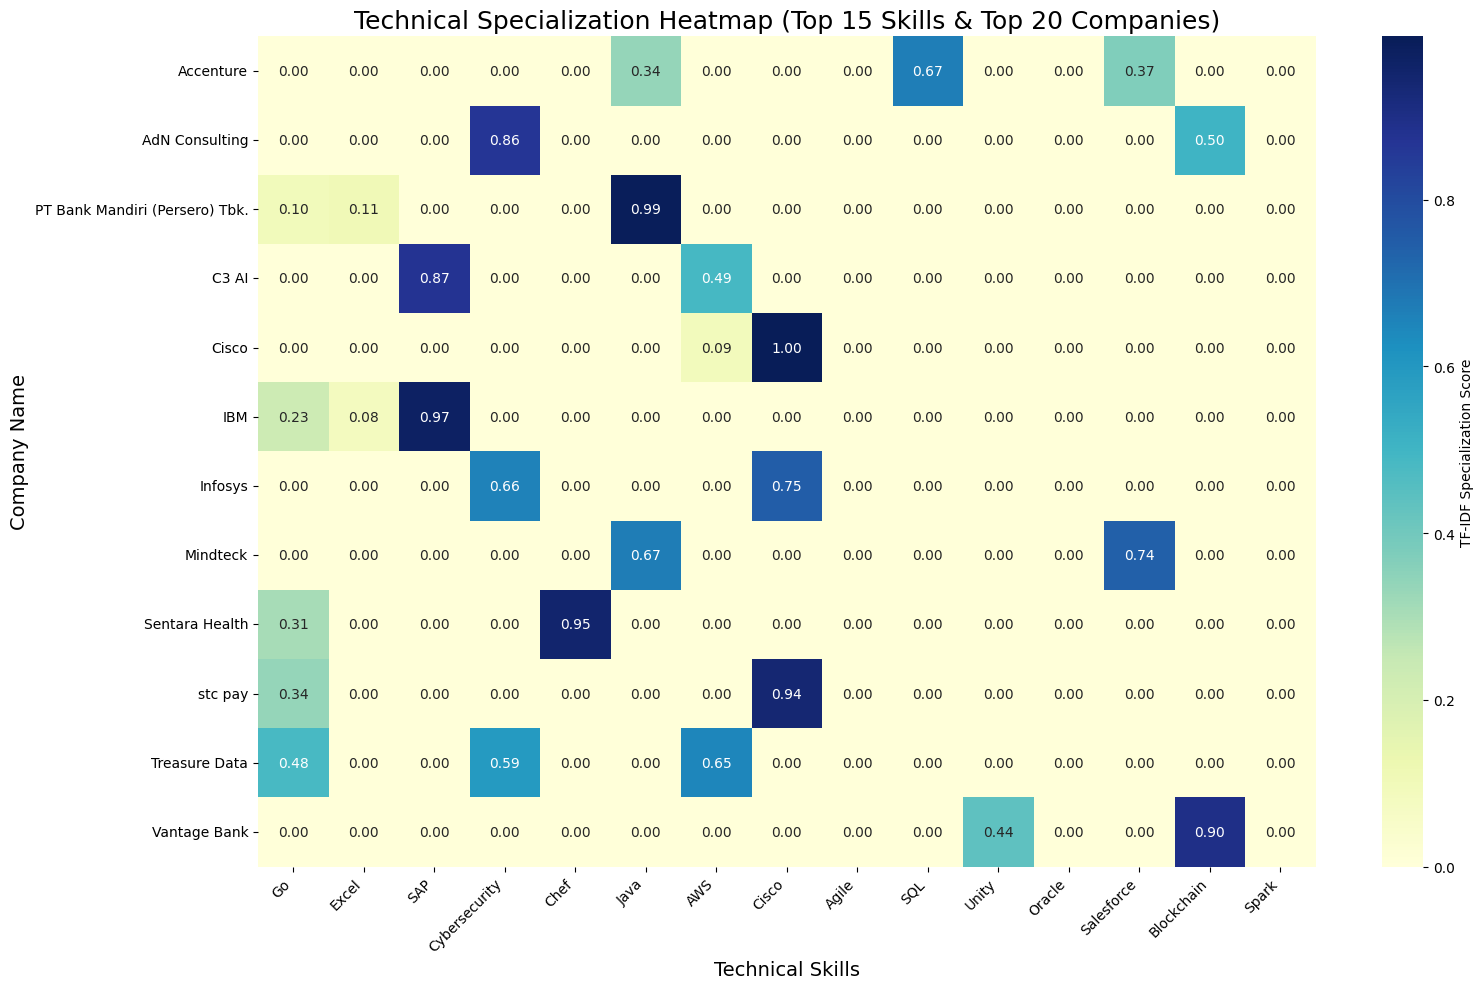

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Identify top 15 skills by summing TF-IDF weights across all companies
top_skills_for_heatmap = tfidf_df.sum().sort_values(ascending=False).head(15).index.tolist()

# 2. Identify top 20 companies based on their total weights in these top skills
top_company_ids_for_heatmap = tfidf_df[top_skills_for_heatmap].sum(axis=1).sort_values(ascending=False).head(20).index.tolist()

# 3. Create a pivot-style dataframe for the heatmap
# We use the filtered_display_df which contains the company names and active weights
heatmap_data_subset = filtered_display_df[filtered_display_df['company_id'].isin(top_company_ids_for_heatmap)]
heatmap_pivot = heatmap_data_subset.set_index('company_name')[top_skills_for_heatmap]

# 4. Plot the heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(heatmap_pivot, annot=True, cmap='YlGnBu', fmt='.2f', cbar_kws={'label': 'TF-IDF Specialization Score'})

plt.title('Technical Specialization Heatmap (Top 15 Skills & Top 20 Companies)', fontsize=18)
plt.xlabel('Technical Skills', fontsize=14)
plt.ylabel('Company Name', fontsize=14)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [40]:
# Save the filtered specialization dataset to a CSV file
output_filename = 'Company_Technical_Specialization_Weights.csv'
filtered_display_df.to_csv(output_filename, index=False)

print(f'Successfully saved the final dataset to: {output_filename}')
print(f'Dataset shape: {filtered_display_df.shape}')

Successfully saved the final dataset to: Company_Technical_Specialization_Weights.csv
Dataset shape: (446, 71)
